## Library Importation

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
print("All libraries imported successfully !")

All libraries imported successfully !


## EDA

In [5]:
df_assess = pd.read_csv('../data/raw/assessments.csv')
df_courses = pd.read_csv('../data/raw/courses.csv')

In [7]:
df_assess.duplicated().sum()

np.int64(1)

In [8]:
df_assess.drop_duplicates(inplace=True)

## Merge and Null Count

In [11]:
merged_df = df_assess.merge(df_courses, on='course_id', how='left')
merged_df

,assessment_id,month,course_id,batch,score,attendance_pct,course,department
0,1,Jan,C1,Morning,72,90,Excel,Business
1,2,Jan,C2,Evening,45,70,PowerBI,Business
2,3,Jan,C3,Morning,65,85,SQL,Technology
3,4,Jan,C4,Weekend,38,60,Python,Technology
4,5,Feb,C1,Evening,80,95,Excel,Business
5,6,Feb,C2,Weekend,55,80,PowerBI,Business
6,7,Feb,C3,Morning,48,75,SQL,Technology
7,8,Feb,C4,Evening,68,88,Python,Technology
8,9,Mar,C1,Weekend,90,98,Excel,Business
9,10,Mar,C2,Morning,60,82,PowerBI,Business


In [12]:
merged_df.isnull().sum()

assessment_id     0
month             0
course_id         0
batch             0
score             0
attendance_pct    0
course            0
department        0
dtype: int64

#### merged df have all 12 records and zero null value.

In [13]:
merged_df['pass_flag'] = (merged_df['score'] >= 50).astype(int)

## Department summary

In [17]:
dept_summary = merged_df.groupby('department').agg(total_assessments=('pass_flag', 'count'), passed=('pass_flag', 'sum')).reset_index()
print(dept_summary)

   department  total_assessments  passed
0    Business                  6       5
1  Technology                  6       3


## Department pass rate (%)

In [16]:
dept_summary['pass_rate_pct'] = (dept_summary['passed'] / dept_summary['total_assessments'] * 100).round(2)

## Course summary

In [18]:
course_summary = merged_df.groupby('course').agg(total_assessments=('pass_flag', 'count'), passed=('pass_flag', 'sum')).reset_index()

## Course pass rate (%)

In [19]:
course_summary['pass_rate_pct'] = (course_summary['passed'] / course_summary['total_assessments'] * 100).round(2)

## Lowest pass rate course

In [20]:
lowest = course_summary.sort_values('pass_rate_pct').iloc[0]

In [21]:
print(f"Lowest pass rate course: {lowest['course']}")
print(f"Numerator (passing count): {lowest['passed']}")
print(f"Denominator (total assessments): {lowest['total_assessments']}")
print(f"Pass rate: {lowest['pass_rate_pct']}%")

Lowest pass rate course: Python
Numerator (passing count): 1
Denominator (total assessments): 3
Pass rate: 33.33%


## Monthly Average Score Chart

(array([0, 1, 2]), [Text(0, 0, 'Jan'), Text(1, 0, 'Feb'), Text(2, 0, 'Mar')])

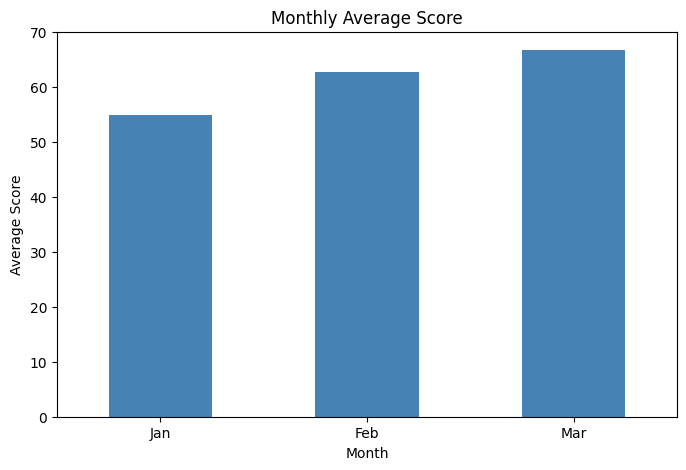

In [24]:
monthly_avg = merged_df.groupby('month')['score'].mean().reindex(['Jan', 'Feb', 'Mar'])

plt.figure(figsize=(8, 5))
monthly_avg.plot(kind='bar', color='steelblue')
plt.title('Monthly Average Score')
plt.xlabel('Month')
plt.ylabel('Average Score')
plt.xticks(rotation=0)

## Saving Outputs

In [25]:
plt.savefig('../outputs/python_chart.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [26]:
merged_df.to_csv('../outputs/clean_data.csv', index=False)

In [27]:
dept_summary.to_csv('../outputs/python_summary.csv', index=False)